In [1]:
import pandas as pd
import numpy as np
import jax.numpy as jnp
import jax
import numpyro
from sklearn.preprocessing import StandardScaler
from sklearn. decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
from numpyro.infer import Predictive, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam
from torch.xpu import device

warnings.filterwarnings('ignore')
numpyro.set_host_device_count(3)

In [2]:
fifa_20 = pd.read_csv('data/players_20.csv')
features = list(fifa_20.columns[fifa_20.dtypes=='int64'])[11:]
target = ['overall']
fifa_20[features].head()

,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,88,95,70,92,88,97,93,94,92,96,...,75,96,33,37,26,6,11,15,14,8
1,84,94,89,83,87,89,81,76,77,92,...,85,95,28,32,24,7,11,15,14,11
2,87,87,62,87,87,96,88,87,81,95,...,90,94,27,26,29,9,9,15,15,11
3,13,11,15,43,13,12,13,14,40,30,...,11,68,27,12,18,87,92,78,90,89
4,81,84,61,89,83,95,83,79,83,94,...,88,91,34,27,22,11,12,6,8,8


In [3]:
scaler_X = StandardScaler()
scaler_X.fit(fifa_20[features].values)

def pre_data(df, scaler_X):

    X = df[features]
    y = np.array(df[target])

    X = scaler_X.transform(X)

    return X,y

X , y = pre_data(fifa_20, scaler_X)

In [4]:
pca = PCA()
pca.fit(X)
CPX = pca.transform(X)

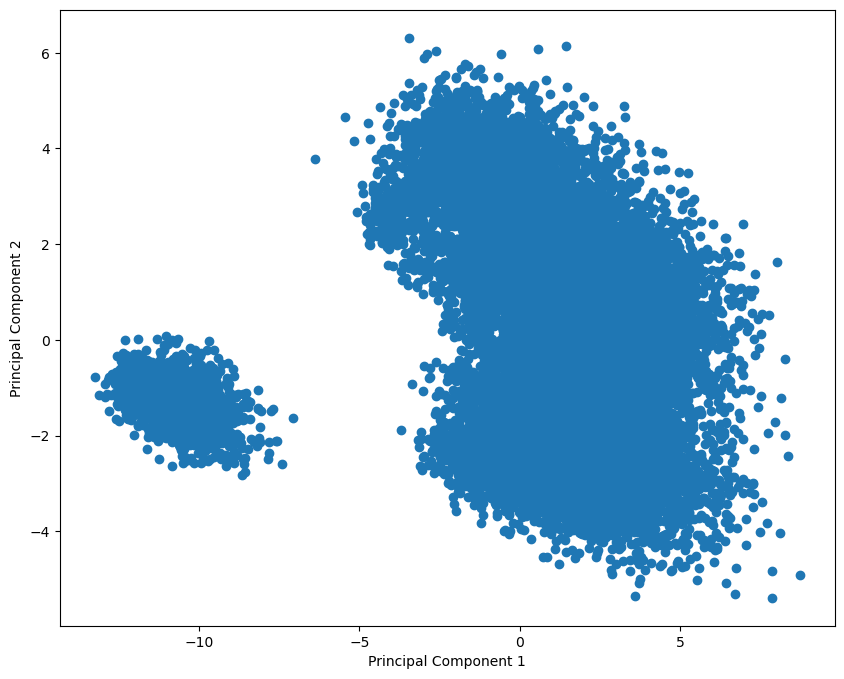

In [5]:
plt.figure(figsize=(10,8))
plt.scatter(CPX[:,0],CPX[:,1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.plot()
plt.show()

In [6]:
kmean = KMeans(n_clusters=4,random_state=1)
kmean.fit(CPX[:,:2])
clusters = kmean.predict(CPX[:,:2])

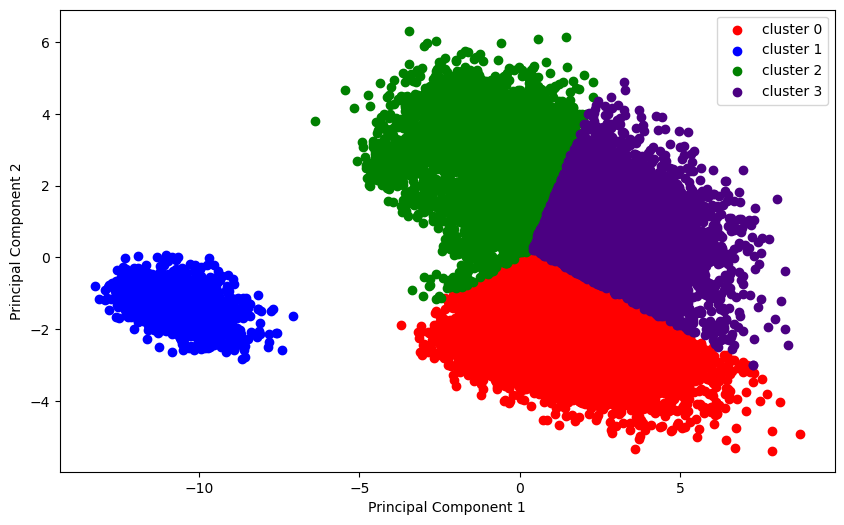

In [7]:
colors=['red','blue','green','indigo']

plt.figure(figsize=(10,6))

for c,col in zip(np.unique(clusters),colors):

    plt.scatter(CPX[clusters==c,0],CPX[clusters==c,1],c=col,label='cluster {}'.format(c))

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.plot()
plt.show()

In [8]:
fifa_20['cluster'] = clusters
fifa_20[['short_name','cluster','player_positions']].query('cluster==0')

,short_name,cluster,player_positions
0,L. Messi,0,"RW, CF, ST"
1,Cristiano Ronaldo,0,"ST, LW"
2,Neymar Jr,0,"LW, CAM"
4,E. Hazard,0,"LW, CF"
9,M. Salah,0,"RW, ST"
...,...,...,...
18248,T. Klysner,0,"LW, LM"
18250,R. Roache,0,ST
18254,E. Jääskeläinen,0,ST
18257,Song Min Kyu,0,LW


In [9]:
fifa_20[['short_name','cluster','nationality','player_positions']].query('cluster==1')

,short_name,cluster,nationality,player_positions
3,J. Oblak,1,Slovenia,GK
6,M. ter Stegen,1,Germany,GK
13,Alisson,1,Brazil,GK
14,De Gea,1,Spain,GK
25,Ederson,1,Brazil,GK
...,...,...,...,...
18231,P. Królczyk,1,Poland,GK
18239,V. Storsve,1,Norway,GK
18251,G. Sykes-Kenworthy,1,England,GK
18259,H. Sveijer,1,Sweden,GK


In [10]:
fifa_20[['short_name','cluster','nationality','player_positions']].query('cluster==2')

,short_name,cluster,nationality,player_positions
11,K. Koulibaly,2,Senegal,CB
57,M. Škriniar,2,Slovakia,CB
77,N. Süle,2,Germany,CB
83,J. Giménez,2,Uruguay,CB
90,K. Manolas,2,Greece,CB
...,...,...,...,...
18273,Shao Shuai,2,China PR,CB
18274,Xiao Mingjie,2,China PR,CB
18275,Zhang Wei,2,China PR,CM
18276,Wang Haijian,2,China PR,CM


In [11]:
fifa_20[['short_name','cluster','nationality','player_positions']].query('cluster==3')

,short_name,cluster,nationality,player_positions
5,K. De Bruyne,3,Belgium,"CAM, CM"
7,V. van Dijk,3,Netherlands,CB
8,L. Modrić,3,Croatia,CM
12,H. Kane,3,England,ST
15,N. Kanté,3,France,"CDM, CM"
...,...,...,...,...
16620,J. Kellermann,3,England,CM
16629,Yao Junsheng,3,China PR,CM
16854,J. Law,3,England,"LWB, LW, ST"
16942,M. Shelton,3,England,CM


In [12]:
fifa_20['position'] = 0

for i in range(fifa_20.shape[0]):

    if fifa_20['cluster'].iloc[i] == 0:

        fifa_20['position'].iloc[i] = 'MED'

    elif fifa_20['cluster'].iloc[i]== 1:

        fifa_20['position'].iloc[i] = 'DEL'

    elif fifa_20['cluster'].iloc[i] == 2:

        fifa_20['position'].iloc[i] = 'POR'

    elif fifa_20['cluster'].iloc[i] == 3:

        fifa_20['position'].iloc[i] = 'DEF'

In [14]:
def recover_original_beta(beta_pca, scaler, pca, y_mean=None, y_std=None):
    """
    Recupera beta_original e intercepto desde:
    - beta_pca (coeficientes en espacio PCA)
    - scaler (StandardScaler)
    - pca (PCA de sklearn)

    Opcional:
    - y_mean, y_std si escalaste y
    """

    # W: (k x p) → necesitamos (p x k)
    W = jnp.array(pca.components_.T)

    # σ (scale)
    scale = jnp.array(scaler.scale_)

    # μ (mean)
    mean = jnp.array(scaler.mean_)

    # Paso 1: volver a espacio estandarizado
    beta_std = W @ beta_pca   # (p,)

    # Paso 2: deshacer scaling
    beta_original = beta_std / scale

    # Paso 3: intercepto
    intercept = -jnp.sum(mean * beta_original)

    # Paso 4: si escalaste y
    if y_mean is not None and y_std is not None:
        beta_original = beta_original * y_std
        intercept = y_mean + y_std * intercept

    return beta_original, intercept

In [23]:
data_gk = fifa_20[fifa_20['position']=='POR']

X_gk = np.array(data_gk[features].values)
y_gk = jnp.array(data_gk[target].values)

#scaler_X_gk = StandardScaler()
#scaler_X_gk.fit(X_gk)

#scale_X_gk = scaler_X_gk.transform(X_gk)

#pca_gk = PCA(n_components=2)
#pca_gk.fit(scale_X_gk)

#pca_X_gk = pca_gk.transform(scale_X_gk)

#X_gk_final = np.concatenate(
 #(np.ones((len(y_gk), 1)).reshape(-1,1), X_gk),
# axis=1)

#X_gk_final = jnp.array(X_gk_final)

In [41]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

data_gk = fifa_20[fifa_20['position'] == 'POR']

X_gk = np.array(data_gk[features].values, dtype=np.float32)
y_gk = np.array(data_gk[target].values, dtype=np.float32)

# bias manual
X_final = np.concatenate(
    [np.ones((X_gk.shape[0], 1), dtype=np.float32), X_gk],
    axis=1
)

X = torch.tensor(X_final, dtype=torch.float32)
y = torch.tensor(y_gk, dtype=torch.float32).unsqueeze(1)  # (N,1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N = X.shape[0]
n_train = int(0.8 * N)
n_test = N - n_train

dataset = TensorDataset(X, y)
train_dataset, test_dataset = random_split(dataset, [n_train, n_test])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

class BayesianLinearRegression(nn.Module):
    def __init__(self, in_features, prior_lambda=1.0):
        super().__init__()

        self.prior_lambda = prior_lambda

        # pesos variacionales
        self.weight_mu = nn.Parameter(torch.zeros(in_features))
        self.weight_rho = nn.Parameter(torch.ones(in_features) * -5)

        # bias libre
        self.bias_mu = nn.Parameter(torch.zeros(1))
        self.bias_rho = nn.Parameter(torch.ones(1) * -5)

    def forward(self, x, n_samples=1):

        sigma_w = torch.log1p(torch.exp(self.weight_rho))
        sigma_b = torch.log1p(torch.exp(self.bias_rho))

        eps_w = torch.randn(n_samples, *self.weight_mu.shape, device=x.device)
        eps_b = torch.randn(n_samples, *self.bias_mu.shape, device=x.device)

        z_w = self.weight_mu + sigma_w * eps_w
        z_b = self.bias_mu + sigma_b * eps_b

        # pesos positivos (prior exponencial)
        w = torch.log1p(torch.exp(z_w))

        # bias libre
        b = z_b

        # predicción
        out = torch.einsum("bi,si->sb", x, w) + b  # (S,B)

        return out.unsqueeze(-1)  # (S,B,1)

    def kl_loss(self, n_samples=1):

        sigma_w = torch.log1p(torch.exp(self.weight_rho))
        sigma_b = torch.log1p(torch.exp(self.bias_rho))

        eps_w = torch.randn(n_samples, *self.weight_mu.shape, device=self.weight_mu.device)
        eps_b = torch.randn(n_samples, *self.bias_mu.shape, device=self.bias_mu.device)

        z_w = self.weight_mu + sigma_w * eps_w
        z_b = self.bias_mu + sigma_b * eps_b

        w = torch.log1p(torch.exp(z_w))
        b = z_b

        # log q
        log_qw = -0.5 * (((z_w - self.weight_mu)/sigma_w)**2 + 2*torch.log(sigma_w) + np.log(2*np.pi))
        log_qb = -0.5 * (((z_b - self.bias_mu)/sigma_b)**2 + 2*torch.log(sigma_b) + np.log(2*np.pi))

        # jacobiano
        log_det = -torch.log1p(torch.exp(-z_w))
        log_qw = log_qw + log_det

        # prior exponencial
        log_pw = torch.log(torch.tensor(self.prior_lambda, device=z_w.device)) - self.prior_lambda * w

        kl = (log_qw - log_pw).sum() + log_qb.sum()

        return kl / n_samples

In [42]:
def elbo(model, x, y, sigma=1.0, n_samples=10, beta=1e-4):

    preds = model(x, n_samples=n_samples)  # (S,B,1)

    S, B, _ = preds.shape

    y_expand = y.unsqueeze(0).expand(S, B, 1)

    nll = ((preds - y_expand)**2 / (2*sigma**2)).sum() / S

    kl = model.kl_loss()

    return nll + beta * kl / B

In [43]:
model = BayesianLinearRegression(X.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50

progress_bar = tqdm(total=num_epochs * len(train_loader))

for epoch in range(num_epochs):
    model.train()

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        loss = elbo(model, x_batch, y_batch)

        loss.backward()
        optimizer.step()

        progress_bar.update(1)
        progress_bar.set_postfix({"loss": f"{loss.item():.3f}"})

progress_bar.close()


Training:   0%|          | 0/1500 [06:13<?, ?it/s]


RuntimeError: expand(torch.cuda.FloatTensor{[1, 128, 1, 1]}, size=[10, 128, 1]): the number of sizes provided (3) must be greater or equal to the number of dimensions in the tensor (4)

100%|██████████| 4500/4500 [00:40<00:00, 112.39it/s, loss=655.862]    


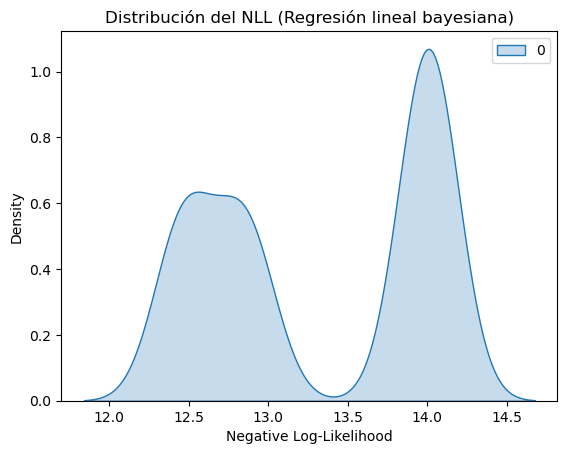

Mean: 13.33394
Std: 0.6891938
Percentiles: [12.44016047 13.42227316 14.06270051]


In [47]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# =========================
# 1. DATOS (SIN ESCALAR)
# =========================
data_gk = fifa_20[fifa_20['position'] == 'POR']

X_gk = np.array(data_gk[features].values, dtype=np.float32)
y_gk = np.array(data_gk[target].values, dtype=np.float32)

# bias manual
X_final = np.concatenate(
    [np.ones((X_gk.shape[0], 1), dtype=np.float32), X_gk],
    axis=1
)

X = torch.tensor(X_final, dtype=torch.float32)
y = torch.tensor(y_gk, dtype=torch.float32)

# 🔥 FIX DEFINITIVO: asegurar (N,1)
y = y.view(-1, 1)

# =========================
# 2. TRAIN / TEST
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N = X.shape[0]
n_train = int(0.8 * N)
n_test = N - n_train

dataset = TensorDataset(X, y)
train_dataset, test_dataset = random_split(dataset, [n_train, n_test])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

# =========================
# 3. MODELO
# =========================
class BayesianLinearRegression(nn.Module):
    def __init__(self, in_features, prior_lambda=1.0):
        super().__init__()

        self.prior_lambda = prior_lambda

        self.weight_mu = nn.Parameter(torch.zeros(in_features))
        self.weight_rho = nn.Parameter(torch.ones(in_features) * -5)

        self.bias_mu = nn.Parameter(torch.zeros(1))
        self.bias_rho = nn.Parameter(torch.ones(1) * -5)

    def forward(self, x, n_samples=1):

        sigma_w = torch.log1p(torch.exp(self.weight_rho))
        sigma_b = torch.log1p(torch.exp(self.bias_rho))

        eps_w = torch.randn(n_samples, *self.weight_mu.shape, device=x.device)
        eps_b = torch.randn(n_samples, *self.bias_mu.shape, device=x.device)

        z_w = self.weight_mu + sigma_w * eps_w
        z_b = self.bias_mu + sigma_b * eps_b

        w = torch.log1p(torch.exp(z_w))   # pesos positivos
        b = z_b                           # bias libre

        out = torch.einsum("bi,si->sb", x, w) + b  # (S,B)

        return out.unsqueeze(-1)  # (S,B,1)

    def kl_loss(self, n_samples=1):

        sigma_w = torch.log1p(torch.exp(self.weight_rho))
        sigma_b = torch.log1p(torch.exp(self.bias_rho))

        eps_w = torch.randn(n_samples, *self.weight_mu.shape, device=self.weight_mu.device)
        eps_b = torch.randn(n_samples, *self.bias_mu.shape, device=self.bias_mu.device)

        z_w = self.weight_mu + sigma_w * eps_w
        z_b = self.bias_mu + sigma_b * eps_b

        w = torch.log1p(torch.exp(z_w))
        b = z_b

        log_qw = -0.5 * (((z_w - self.weight_mu)/sigma_w)**2 + 2*torch.log(sigma_w) + np.log(2*np.pi))
        log_qb = -0.5 * (((z_b - self.bias_mu)/sigma_b)**2 + 2*torch.log(sigma_b) + np.log(2*np.pi))

        log_det = -torch.log1p(torch.exp(-z_w))
        log_qw = log_qw + log_det

        log_pw = torch.log(torch.tensor(self.prior_lambda, device=z_w.device)) - self.prior_lambda * w

        kl = (log_qw - log_pw).sum() + log_qb.sum()

        return kl / n_samples

# =========================
# 4. ELBO
# =========================
def elbo(model, x, y, sigma=1.0, n_samples=10, beta=1e-4):

    preds = model(x, n_samples=n_samples)  # (S,B,1)
    S, B, _ = preds.shape

    # 🔥 FIX DEFINITIVO
    y = y.view(-1, 1)
    y_expand = y.view(1, B, 1).expand(S, B, 1)

    nll = ((preds - y_expand)**2 / (2*sigma**2)).sum() / S

    kl = model.kl_loss()

    return nll + beta * kl / B

# =========================
# 5. ENTRENAMIENTO
# =========================
model = BayesianLinearRegression(X.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 150

progress_bar = tqdm(total=num_epochs * len(train_loader))

for epoch in range(num_epochs):
    model.train()

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device).view(-1, 1)  # 🔥 FIX

        optimizer.zero_grad()

        loss = elbo(model, x_batch, y_batch)

        loss.backward()
        optimizer.step()

        progress_bar.update(1)
        progress_bar.set_postfix({"loss": f"{loss.item():.3f}"})

progress_bar.close()

# =========================
# 6. SAMPLE NLL
# =========================
def sample_nll(model, loader, n_samples=200, sigma=1.0):
    model.eval()

    all_nll = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).view(-1, 1)  # 🔥 FIX

            preds = model(X_batch, n_samples=n_samples)

            S, B, _ = preds.shape

            y_expand = y_batch.view(1, B, 1).expand(S, B, 1)

            nll = ((preds - y_expand)**2 / (2*sigma**2)).mean(dim=1)

            all_nll.append(nll.cpu().numpy())

    return np.concatenate(all_nll)

# =========================
# 7. VISUALIZACIÓN
# =========================
nll_samples = sample_nll(model, test_loader, 200)

sns.kdeplot(nll_samples, fill=True)
plt.xlabel("Negative Log-Likelihood")
plt.title("Distribución del NLL (Regresión lineal bayesiana)")
plt.show()

print("Mean:", np.mean(nll_samples))
print("Std:", np.std(nll_samples))
print("Percentiles:", np.percentile(nll_samples, [5, 50, 95]))

In [48]:
def predict_bnn(model, X, n_samples=200):
    model.eval()

    X = X.to(device)

    with torch.no_grad():
        preds = model(X, n_samples=n_samples)  # (S, B, 1)

        mean = preds.mean(dim=0)   # (B,1)
        std = preds.std(dim=0)     # (B,1)

    return mean.cpu().numpy(), std.cpu().numpy()

In [49]:
# juntar todo el test set
X_test_list = []
y_test_list = []

for X_batch, y_batch in test_loader:
    X_test_list.append(X_batch)
    y_test_list.append(y_batch)

X_test = torch.cat(X_test_list, dim=0)
y_test = torch.cat(y_test_list, dim=0)

# 🔥 predicciones
mean_pred, std_pred = predict_bnn(model, X_test, n_samples=200)

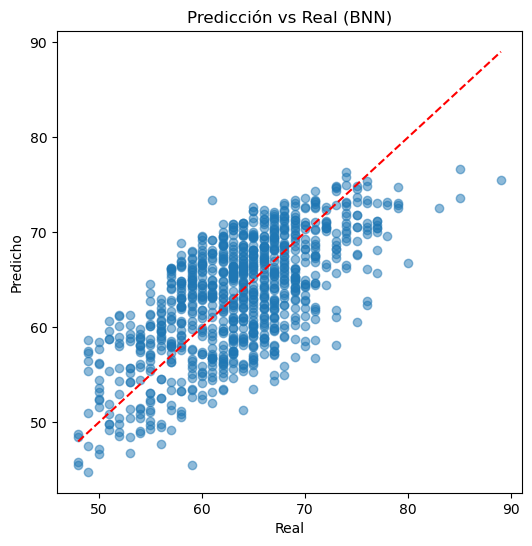

In [50]:
import matplotlib.pyplot as plt

y_true = y_test.numpy()

plt.figure(figsize=(6,6))
plt.scatter(y_true, mean_pred, alpha=0.5)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Predicción vs Real (BNN)")
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--')
plt.show()

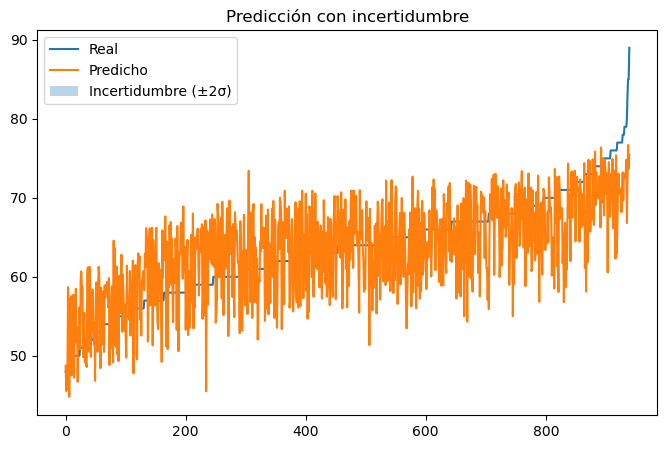

In [51]:
# intervalos 95%
lower = mean_pred - 2 * std_pred
upper = mean_pred + 2 * std_pred

# ordenar para visualización
idx = np.argsort(y_true.flatten())

plt.figure(figsize=(8,5))
plt.plot(y_true[idx], label="Real")
plt.plot(mean_pred[idx], label="Predicho")
plt.fill_between(
    range(len(y_true)),
    lower[idx].flatten(),
    upper[idx].flatten(),
    alpha=0.3,
    label="Incertidumbre (±2σ)"
)

plt.legend()
plt.title("Predicción con incertidumbre")
plt.show()

In [52]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_true, mean_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)
print("Mean pred:", mean_pred.mean())
print("Std pred (avg):", std_pred.mean())

RMSE: 5.151833602255806
Mean pred: 63.36184
Std pred (avg): 0.08170896


In [53]:
mean_pred

array([[65.88629 ],
       [56.45384 ],
       [56.13024 ],
       [65.86669 ],
       [60.123085],
       [59.11252 ],
       [58.441475],
       [62.39236 ],
       [65.3694  ],
       [53.29374 ],
       [68.15526 ],
       [52.631233],
       [65.14174 ],
       [67.52875 ],
       [72.58037 ],
       [51.33209 ],
       [66.242134],
       [67.95987 ],
       [64.6736  ],
       [73.34385 ],
       [58.047157],
       [56.709267],
       [62.986217],
       [72.54035 ],
       [72.73047 ],
       [57.47191 ],
       [62.643066],
       [49.86336 ],
       [63.91326 ],
       [56.364346],
       [69.146255],
       [60.24327 ],
       [69.57683 ],
       [56.21577 ],
       [66.313576],
       [69.41073 ],
       [68.2403  ],
       [63.08177 ],
       [65.85722 ],
       [68.20067 ],
       [64.43549 ],
       [56.364433],
       [64.23727 ],
       [72.698296],
       [57.250725],
       [71.03635 ],
       [65.5237  ],
       [64.61779 ],
       [59.29822 ],
       [52.348312],


In [54]:
y_test

tensor([[67.],
        [59.],
        [50.],
        [67.],
        [55.],
        [61.],
        [64.],
        [68.],
        [68.],
        [58.],
        [65.],
        [59.],
        [63.],
        [65.],
        [79.],
        [57.],
        [61.],
        [64.],
        [58.],
        [71.],
        [54.],
        [59.],
        [58.],
        [83.],
        [74.],
        [63.],
        [62.],
        [56.],
        [67.],
        [57.],
        [66.],
        [53.],
        [62.],
        [62.],
        [72.],
        [65.],
        [70.],
        [68.],
        [59.],
        [63.],
        [61.],
        [61.],
        [69.],
        [71.],
        [67.],
        [71.],
        [59.],
        [60.],
        [53.],
        [55.],
        [59.],
        [50.],
        [62.],
        [75.],
        [76.],
        [64.],
        [61.],
        [55.],
        [60.],
        [57.],
        [52.],
        [65.],
        [60.],
        [52.],
        [57.],
        [73.],
        [6

In [55]:
def sample_weights(model, n_samples=1000):

    with torch.no_grad():

        sigma_w = torch.log1p(torch.exp(model.weight_rho))
        sigma_b = torch.log1p(torch.exp(model.bias_rho))

        eps_w = torch.randn(n_samples, *model.weight_mu.shape, device=model.weight_mu.device)
        eps_b = torch.randn(n_samples, *model.bias_mu.shape, device=model.bias_mu.device)

        z_w = model.weight_mu + sigma_w * eps_w
        z_b = model.bias_mu + sigma_b * eps_b

        # tu transformación del modelo
        w = torch.log1p(torch.exp(z_w))  # pesos positivos
        b = z_b

    return w.cpu().numpy(), b.cpu().numpy()

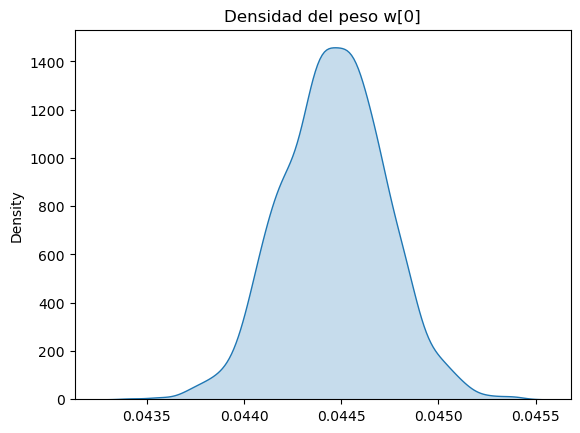

In [62]:
w_samples, b_samples = sample_weights(model, n_samples=2000)

plt.figure()
sns.kdeplot(w_samples[:, 6], fill=True)
plt.title("Densidad del peso w[0]")
plt.show()

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [25]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# pasar de jax → numpy → torch
X = torch.tensor(np.array(X_gk_final), dtype=torch.float32)
y = torch.tensor(np.array(y_gk), dtype=torch.float32).unsqueeze(1)

# =========================
# train / test split
# =========================
N = X.shape[0]
n_train = int(0.8 * N)
n_test = N - n_train

dataset = TensorDataset(X, y)
train_dataset, test_dataset = random_split(dataset, [n_train, n_test])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

In [26]:
N = X.shape[0]
n_train = int(0.8 * N)
n_test = N - n_train

dataset = TensorDataset(X, y)
train_dataset, test_dataset = random_split(dataset, [n_train, n_test])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import copy
import numpy as np

In [34]:
class BayesianLinearExp(nn.Module):
    def __init__(self, in_features, out_features, prior_lambda=1.0):
        super().__init__()
        self.prior_lambda = prior_lambda

        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_rho = nn.Parameter(torch.empty(out_features, in_features))

        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_rho = nn.Parameter(torch.empty(out_features))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_normal_(self.weight_mu)
        self.weight_rho.data.fill_(-5)

        nn.init.zeros_(self.bias_mu)
        self.bias_rho.data.fill_(-5)

    def forward(self, x, n_samples=1):

        sigma_w = torch.log1p(torch.exp(self.weight_rho))
        sigma_b = torch.log1p(torch.exp(self.bias_rho))

        if x.dim() == 2:
            x = x.unsqueeze(0).expand(n_samples, *x.shape)

        S = x.size(0)

        eps_w = torch.randn(S, *self.weight_mu.shape, device=x.device)
        eps_b = torch.randn(S, *self.bias_mu.shape, device=x.device)

        z_w = self.weight_mu + sigma_w * eps_w
        z_b = self.bias_mu + sigma_b * eps_b

        # 🔥 pesos positivos
        weight = torch.log1p(torch.exp(z_w))
        bias = torch.log1p(torch.exp(z_b))

        out = torch.einsum("sbi,soi->sbo", x, weight) + bias.unsqueeze(1)

        return out

In [35]:
def kl_loss(self, n_samples=1):

    sigma_w = torch.log1p(torch.exp(self.weight_rho))
    sigma_b = torch.log1p(torch.exp(self.bias_rho))

    eps_w = torch.randn(n_samples, *self.weight_mu.shape, device=self.weight_mu.device)
    eps_b = torch.randn(n_samples, *self.bias_mu.shape, device=self.bias_mu.device)

    z_w = self.weight_mu + sigma_w * eps_w
    z_b = self.bias_mu + sigma_b * eps_b

    w = torch.log1p(torch.exp(z_w))
    b = torch.log1p(torch.exp(z_b))

    # log q(z)
    log_qw = -0.5 * (((z_w - self.weight_mu)/sigma_w)**2 + 2*torch.log(sigma_w) + np.log(2*np.pi))
    log_qb = -0.5 * (((z_b - self.bias_mu)/sigma_b)**2 + 2*torch.log(sigma_b) + np.log(2*np.pi))

    # cambio de variable (Jacobian softplus)
    log_det_jac_w = -torch.log1p(torch.exp(-z_w))
    log_det_jac_b = -torch.log1p(torch.exp(-z_b))

    log_qw = log_qw + log_det_jac_w
    log_qb = log_qb + log_det_jac_b

    # log prior exponencial
    log_pw = torch.log(torch.tensor(self.prior_lambda)) - self.prior_lambda * w
    log_pb = torch.log(torch.tensor(self.prior_lambda)) - self.prior_lambda * b

    kl = (log_qw - log_pw).sum() + (log_qb - log_pb).sum()

    return kl / n_samples

In [36]:
class BayesianNNReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = BayesianLinearExp(1, 64)
        self.fc2 = BayesianLinearExp(64, 64)
        self.fc3 = BayesianLinearExp(64, 1)

    def forward(self, x, n_samples=1):
        x = torch.relu(self.fc1(x, n_samples))
        x = torch.relu(self.fc2(x, n_samples))
        x = self.fc3(x, n_samples)
        return x

    def kl_loss(self):
        return self.fc1.kl_loss() + self.fc2.kl_loss() + self.fc3.kl_loss()

In [37]:
def elbo_regression(model, x, y, sigma=1.0, n_samples=10, beta=0.01):

    preds = model(x, n_samples=n_samples)  # (S,B,1)
    S, B, _ = preds.shape

    y_expand = y.unsqueeze(0).expand(S, B, 1)

    # negative log-likelihood
    nll = ((preds - y_expand)**2 / (2*sigma**2)).sum() / S

    kl = model.kl_loss()

    return nll + beta * kl / B

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [39]:
def sample_nll(model, X_test, y_test, sigma=1.0, n_samples=200):
    model.eval()

    X_test = X_test.to(device)
    y_test = y_test.to(device)

    with torch.no_grad():
        preds = model(X_test, n_samples=n_samples)  # (S,N,1)

        y_expand = y_test.unsqueeze(0).expand(n_samples, -1, 1)

        nll = ((preds - y_expand)**2 / (2*sigma**2)).mean(dim=1)

    return nll.squeeze().cpu().numpy()

In [40]:
from tqdm import tqdm
model = BayesianNNReg().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 50
beta = 0.01

progress_bar = tqdm(total=num_epochs * len(train_loader), desc="Training")

for epoch in range(num_epochs):
    model.train()

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        loss = elbo_regression(
            model,
            x_batch,
            y_batch,
            sigma=1.0,
            n_samples=10,
            beta=beta
        )

        loss.backward()
        optimizer.step()

        progress_bar.update(1)
        progress_bar.set_postfix({
            "epoch": epoch,
            "loss": f"{loss.item():.3f}"
        })

progress_bar.close()

Training:   0%|          | 0/1500 [00:00<?, ?it/s]

RuntimeError: expand(torch.cuda.FloatTensor{[1, 128, 1, 1]}, size=[10, 128, 1]): the number of sizes provided (3) must be greater or equal to the number of dimensions in the tensor (4)

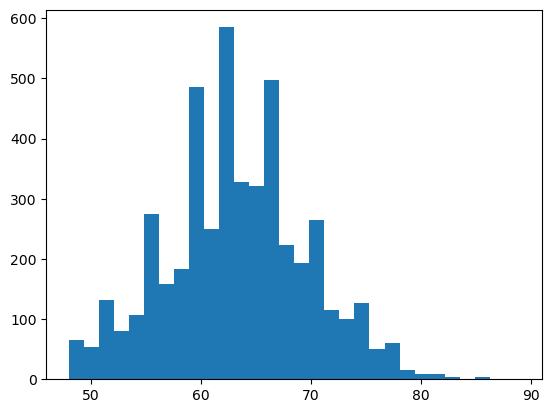

In [15]:
plt.hist(y_gk, bins=30)
plt.show()

In [77]:
def linear_reg_model(X, y=None):

    n, p = X.shape

    beta = numpyro.sample(
        "beta",
        numpyro.distributions.HalfNormal(1.0).expand([p]).to_event(1)
    )

    sigma = numpyro.sample(
        "sigma",
        numpyro.distributions.HalfNormal(1.0)
    )

    mu = jnp.dot(X, beta)

    with numpyro.plate("plate", n, subsample_size=50) as idx:

        mu = jnp.dot(X[idx], beta)

        numpyro.sample(
        "obs",
        numpyro.distributions.Normal(mu, sigma),
        obs=y[idx]
    )

In [78]:
guide = AutoNormal(linear_reg_model)

In [83]:
lr = 3e-3
optimizer = numpyro.optim.Adam(lr)

svi = SVI(
    linear_reg_model,
    guide,
    optimizer,
    loss=Trace_ELBO()
)
rng_key = jax.random.PRNGKey(18081997)

svi_result = svi.run(
    rng_key,
    1000000,
    X_gk_final,
    y_gk,
    progress_bar=True
)

100%|██████████| 1000000/1000000 [06:51<00:00, 2432.46it/s, init loss: 151158849536.0000, avg. loss [950001-1000000]: 773132.8750]


In [84]:


predictive_guide = Predictive(
    guide,
    params=svi_result.params,
    num_samples=1000
)

samples = predictive_guide(jax.random.PRNGKey(1), X_gk_final)

beta_samples = samples["beta"]
sigma_samples = samples["sigma"]

In [85]:
((y_gk[None, :]-jnp.dot(X_gk_final, beta_samples.T))**2).mean(axis=1)

Array([[38.893486, 38.819183, 38.803974, 38.921448, 38.81595 , 38.81057 ,
        38.934834, 38.830944, 38.884296, 38.855705, 38.87172 , 38.832195,
        38.93335 , 38.91382 , 38.91082 , 38.87134 , 38.8228  , 38.93779 ,
        38.851105, 38.909756, 38.782578, 38.8824  , 38.910973, 38.83844 ,
        38.930313, 38.867275, 38.918785, 38.853065, 38.81852 , 38.934727,
        38.852585, 38.81352 , 38.868427, 38.878742, 38.870594, 38.92848 ,
        38.82198 , 38.848946, 38.806168, 38.842674, 38.83268 , 38.86334 ,
        38.856617, 38.919266, 38.83212 , 38.83842 , 38.9104  , 38.83953 ,
        38.88865 , 38.77024 , 38.806786, 38.954197, 38.924957, 38.764267,
        38.84415 , 38.936954, 38.83599 , 38.918095, 38.951218, 38.887596,
        38.781616, 38.93317 , 38.89391 , 38.838566, 38.922   , 38.88359 ,
        38.832813, 38.88267 , 38.914547, 38.942074, 38.889965, 38.8448  ,
        38.85643 , 38.87093 , 38.856606, 38.888924, 38.976933, 38.883316,
        38.804657, 38.83755 , 38.96573

In [23]:
recover_original_beta(beta_pca, scaler_X_gk, pca_gk)

(Array([-1.29983920e-04, -1.69487583e-04,  6.77394428e-06, -1.68462924e-04,
        -1.56743379e-04, -1.67521415e-04, -1.67465507e-04, -1.50279695e-04,
        -1.32495697e-04, -2.01699484e-04, -6.42234081e-05, -6.03541812e-05,
        -1.01528189e-04, -1.14841045e-04, -6.33767704e-05, -8.74027901e-05,
         1.42830240e-05, -7.66654121e-05,  2.76067967e-05, -1.47430983e-04,
        -4.90459061e-05, -4.51236701e-05, -1.43606405e-04, -1.74055414e-04,
        -1.18652664e-04, -7.41618205e-05, -2.74079794e-05, -2.33284536e-05,
        -3.34663673e-05, -3.69714362e-05, -6.60354999e-05, -3.95451971e-05,
        -3.57297504e-05, -4.53973225e-05], dtype=float32),
 Array(0.13078372, dtype=float32))

In [24]:
model_gk.summary_metrics(X_gk_final, y_gk)

ValueError: All input arrays must have the same shape.

In [25]:
model_gk.plot_nll_density(X_gk_final, y_gk)

ValueError: All input arrays must have the same shape.

In [26]:
model_gk.

(Array([63.225433, 63.215694, 63.224915, ..., 63.26364 , 63.25997 ,
        63.262196], dtype=float32),
 Array([63.36746 , 63.34101 , 63.364784, ..., 63.380245, 63.374737,
        63.37698 ], dtype=float32))